# Support Vector Machine (SVM)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid_svm = run_grid_search(
    SVC(kernel="linear", class_weight=class_weight_dict, probability=True, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
svm_l = grid_svm.best_estimator_

y_pred_svm = svm_l.predict(X_test_scaled)
y_prob_svm = svm_l.predict_proba(X_test_scaled)
y_dec_svm  = svm_l.decision_function(X_test_scaled)

class_names, classes, colors = get_class_meta()

print("Linear SVM training complete.")
print(f"Best C used: {grid_svm.best_params_['C']}")
print(f"Support vectors per class: {svm_l.n_support_}")
print(f"Total support vectors: {svm_l.n_support_.sum()}/{X_train_bal.shape[0]} training samples")

Linear SVM training complete.
Best C used: 100
Support vectors per class: [22 17 26]
Total support vectors: 65/697 training samples


## Modeling
### DIAGNOSTIC PLOT 1: Feature Coefficients

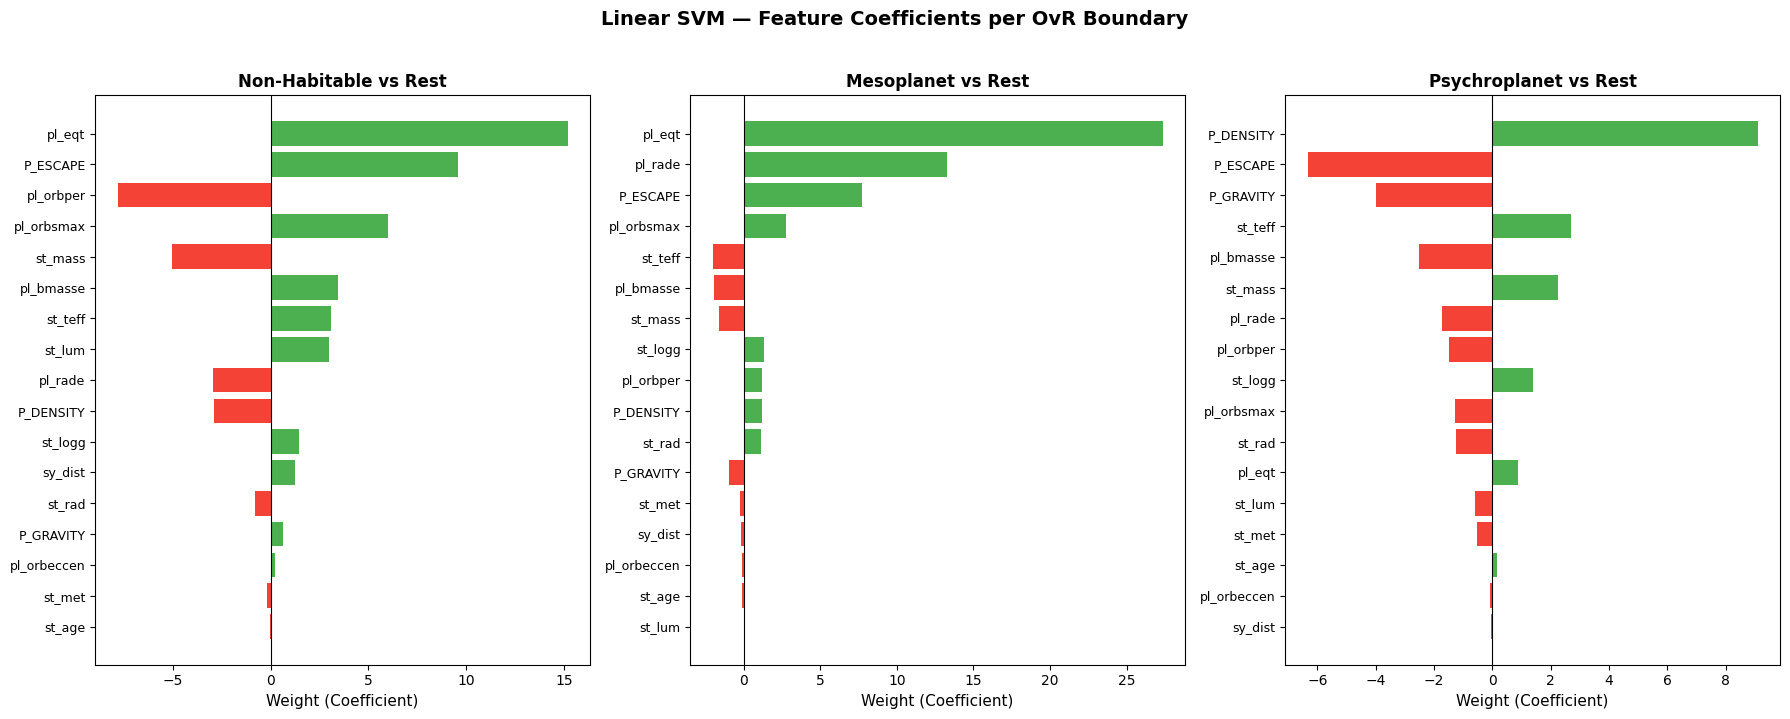

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
boundary_labels = ["Non-Habitable vs Rest", "Mesoplanet vs Rest", "Psychroplanet vs Rest"]

for cls_idx, ax in enumerate(axes):
    weights = svm_l.coef_[cls_idx]
    sorted_idx = np.argsort(np.abs(weights))[::-1]
    sorted_weights = weights[sorted_idx]
    sorted_names = [FEATURES[i] for i in sorted_idx]
    bar_colors = ["#4CAF50" if w > 0 else "#F44336" for w in sorted_weights]

    ax.barh(range(len(sorted_names)), sorted_weights, color=bar_colors, edgecolor="none")
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Weight (Coefficient)", fontsize=11)
    ax.set_title(boundary_labels[cls_idx], fontsize=12, fontweight="bold")

fig.suptitle("Linear SVM — Feature Coefficients per OvR Boundary",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("svm_feature_coefficients")
plt.show()

### DIAGNOSTIC PLOT 2: Decision Function Score Distributions by True Class

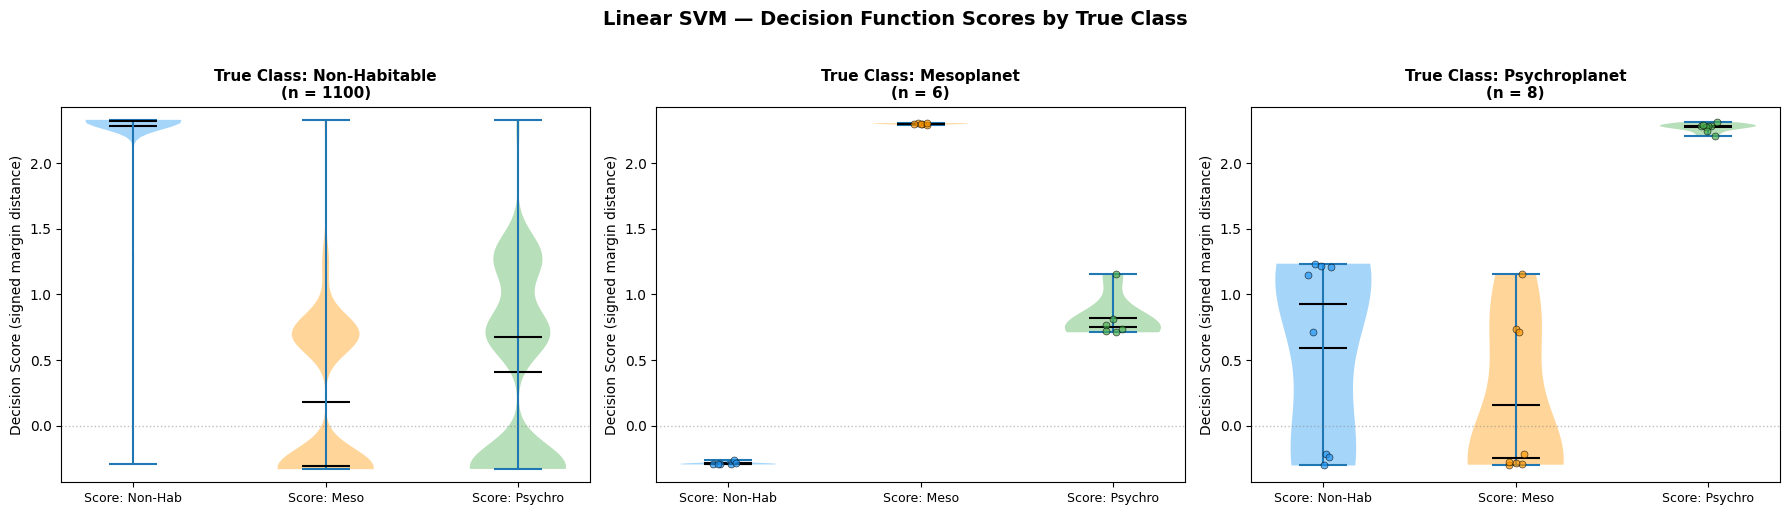

↑ Positive score = model pushes sample toward that class boundary.
  For a correctly classified sample, the true class score should be the highest.
  Score = 0 is the decision boundary — samples near 0 are the most uncertain.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_labels = ["Score: Non-Hab", "Score: Meso", "Score: Psychro"]
y_test_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

for true_cls in range(3):
    ax = axes[true_cls]
    mask = y_test_arr == float(true_cls)
    scores = y_dec_svm[mask]

    if scores.shape[0] == 0:
        ax.set_title(f"True: {class_names[true_cls]}\n(no samples)")
        continue

    parts = ax.violinplot(
        [scores[:, c] for c in range(3)],
        positions=[0, 1, 2],
        showmeans=True,
        showmedians=True,
    )
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.4)
    for key in ("cmeans", "cmedians"):
        if key in parts:
            parts[key].set_color("black")

    if scores.shape[0] <= 50:
        rng = np.random.default_rng(42)
        for c in range(3):
            jitter = rng.normal(0, 0.04, size=scores.shape[0])
            ax.scatter(
                np.full(scores.shape[0], c) + jitter,
                scores[:, c],
                color=colors[c], s=25, alpha=0.7,
                edgecolors="black", linewidth=0.5, zorder=5,
            )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(score_labels, fontsize=9)
    ax.set_ylabel("Decision Score (signed margin distance)")
    ax.set_ylim(y_dec_svm.min() - 0.1, y_dec_svm.max() + 0.1)
    ax.axhline(0, color="gray", ls=":", lw=1, alpha=0.5)
    ax.set_title(f"True Class: {class_names[true_cls]}\n(n = {mask.sum()})",
                 fontsize=11, fontweight="bold")

fig.suptitle("Linear SVM — Decision Function Scores by True Class",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("svm_decision_scores")
plt.show()

print("↑ Positive score = model pushes sample toward that class boundary.")
print("  For a correctly classified sample, the true class score should be the highest.")
print("  Score = 0 is the decision boundary — samples near 0 are the most uncertain.")

### DIAGNOSTIC PLOT 3: Support Vectors in PCA Space

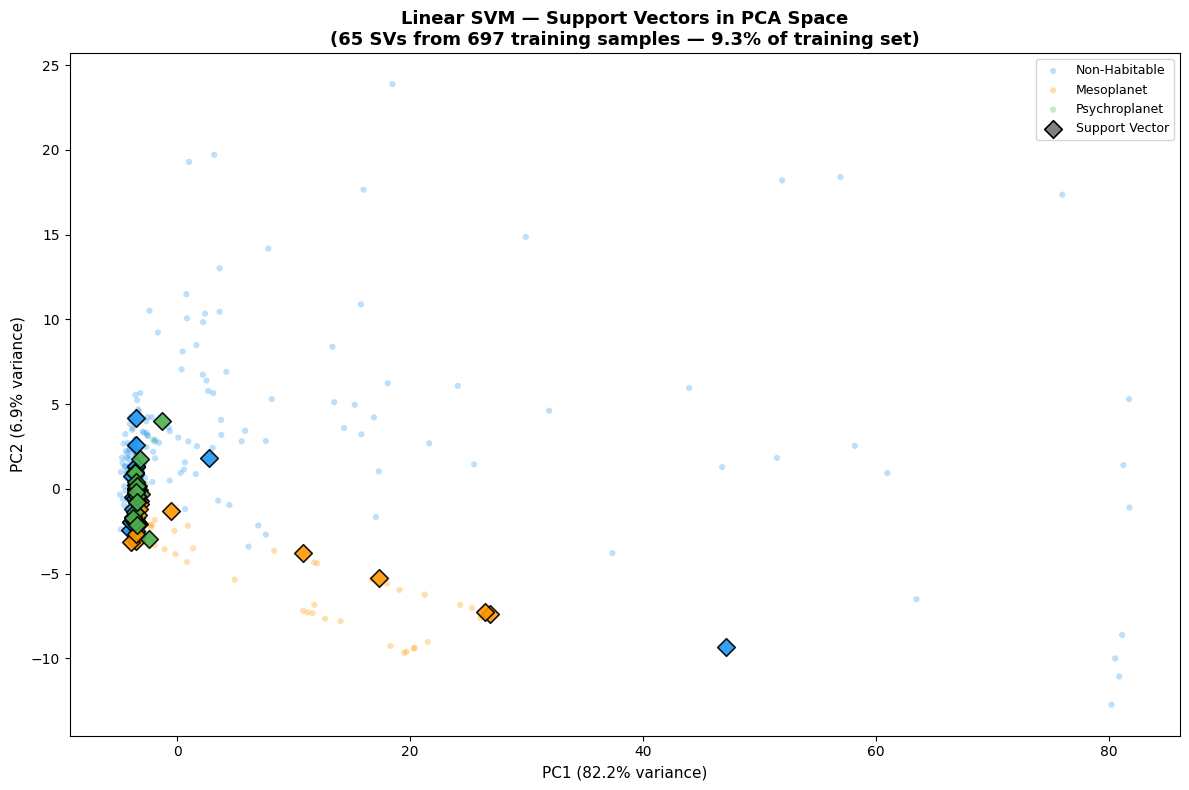

Support vectors per class: {'Non-Habitable': np.int32(22), 'Mesoplanet': np.int32(17), 'Psychroplanet': np.int32(26)}


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)

sv_mask = np.zeros(X_train_bal.shape[0], dtype=bool)
sv_mask[svm_l.support_] = True

y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)

fig, ax = plt.subplots(figsize=(12, 8))

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_train_arr == cls
    ax.scatter(X_train_pca[mask & ~sv_mask, 0], X_train_pca[mask & ~sv_mask, 1],
               c=color, label=label, alpha=0.3, s=20, edgecolors="none")
    ax.scatter(X_train_pca[mask & sv_mask, 0], X_train_pca[mask & sv_mask, 1],
               c=color, s=80, alpha=0.9, edgecolors="black", linewidth=1.2,
               marker="D", zorder=5)

ax.scatter([], [], c="gray", s=80, marker="D", edgecolors="black",
           linewidth=1.2, label="Support Vector")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(
    f"Linear SVM — Support Vectors in PCA Space\n"
    f"({svm_l.n_support_.sum()} SVs from {X_train_bal.shape[0]} training samples — "
    f"{svm_l.n_support_.sum() / X_train_bal.shape[0]:.1%} of training set)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("svm_support_vectors_pca")
plt.show()

print(f"Support vectors per class: {dict(zip(class_names, svm_l.n_support_))}")

## Metrics
### Classification Report + F1 Scores

SVM — Classification Report
               precision    recall  f1-score   support

Non-Habitable     1.0000    0.9755    0.9876      1100
   Mesoplanet     0.3333    1.0000    0.5000         6
Psychroplanet     0.3478    1.0000    0.5161         8

     accuracy                         0.9758      1114
    macro avg     0.5604    0.9918    0.6679      1114
 weighted avg     0.9917    0.9758    0.9816      1114

F1 Macro:    0.6679
F1 Weighted: 0.9816

5-Fold CV F1 Macro: 0.9693 ± 0.0179
F1 Macro:    0.6679
F1 Weighted: 0.9816


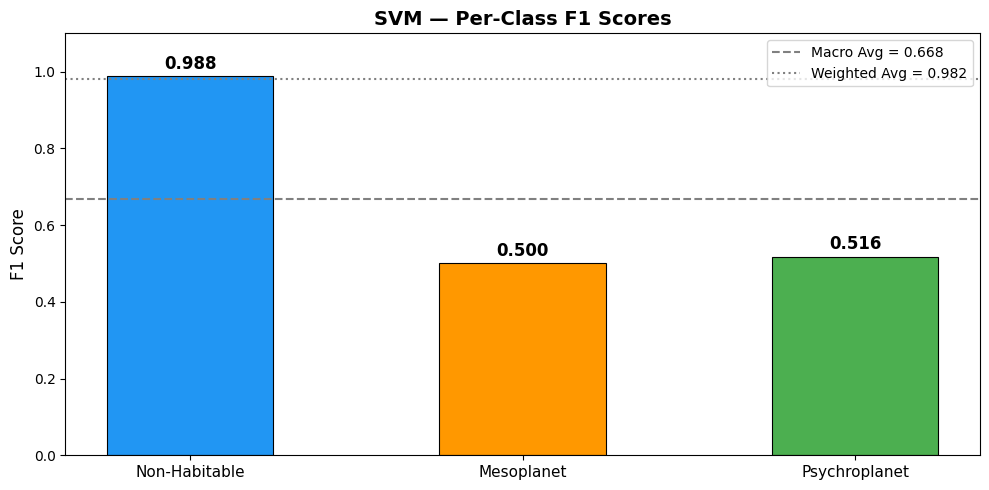

In [7]:
print_classification_report(y_test, y_pred_svm, "SVM")

f1_macro_svm, f1_weighted_svm, _ = compute_f1_scores(y_test, y_pred_svm)

cv_scores_svm = run_stratified_cv(svm_l, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_svm, "SVM")

### Confusion Matrix (Counts + Normalized)

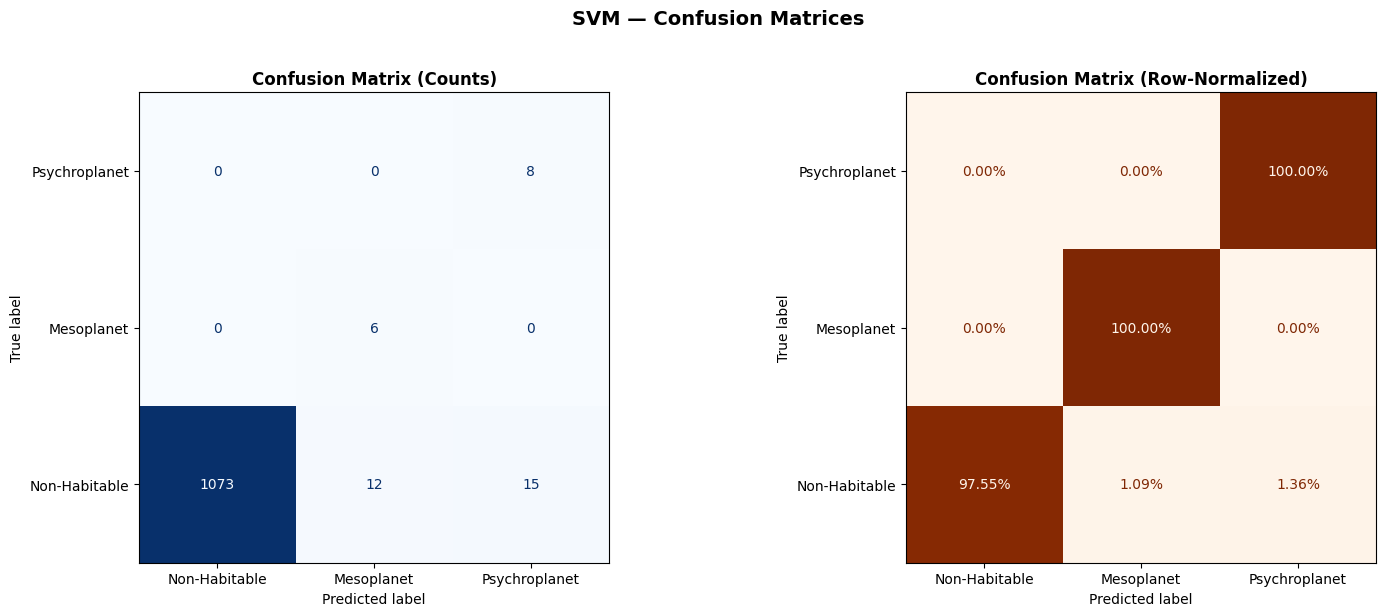

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 12 (1.1% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 15 (1.4% of true Non-Habitable)


In [8]:
plot_confusion_matrices(y_test, y_pred_svm, "SVM")
print_error_patterns(y_test, y_pred_svm)

## Interpretation:
